In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df_raw = pd.read_csv("src/data/raw/retail_price.csv")
df_raw.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

In [27]:
df_raw.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [28]:
df = df_raw.rename(
    columns={
        "month_year": "date",       # time index
        "qty": "units_sold",        # demand
        "unit_price": "price",      # our price
        "total_price": "revenue",   # already price * qty
    }
).copy()

In [29]:
df["date"] = pd.to_datetime(df["date"])

In [30]:
critical_cols = ["date", "product_id", "price", "units_sold"]
df = df.dropna(subset=critical_cols)
df = df[df["price"] > 0]
df = df[df["units_sold"] >= 0]
df.head()

,product_id,product_category_name,date,units_sold,revenue,freight_price,price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,2017-01-05,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,2017-01-06,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,2017-01-07,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,2017-01-08,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,2017-01-09,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [31]:
comp_cols = ["comp_1", "comp_2", "comp_3"]
df["competitor_price_mean"] = df[comp_cols].mean(axis=1)

In [32]:
df["competitor_price_gap"] = df["price"] - df["competitor_price_mean"]

In [33]:
group_cols = ["product_id", "date"]
df_monthly = (
    df.groupby(group_cols, as_index=False)
      .agg(
          units_sold=("units_sold", "sum"),
          avg_price=("price", "mean"),
          revenue=("revenue", "sum"),
          avg_competitor_price=("competitor_price_mean", "mean"),
          avg_competitor_gap=("competitor_price_gap", "mean"),
          customers=("customers", "sum"),
          weekday_days=("weekday", "sum"),
          weekend_days=("weekend", "sum"),
          holiday_days=("holiday", "sum"),
      )
)
df_monthly.head()

,product_id,date,units_sold,avg_price,revenue,avg_competitor_price,avg_competitor_gap,customers,weekday_days,weekend_days,holiday_days
0,bed1,2017-01-05,1,45.95,45.95,116.950000,-71.000000,57,23,8,1
1,bed1,2017-01-06,3,45.95,137.85,114.950000,-69.000000,61,22,8,1
2,bed1,2017-01-07,6,45.95,275.70,113.616667,-67.666667,123,21,10,1
3,bed1,2017-01-08,4,45.95,183.80,111.786601,-65.836601,90,23,8,1
4,bed1,2017-01-09,2,45.95,91.90,99.749570,-53.799570,54,21,9,1


In [34]:
# Overall distributions
df["units_sold"].describe(), df["price"].describe(), df["revenue"].describe()

(count    676.000000
 mean      14.495562
 std       15.443421
 min        1.000000
 25%        4.000000
 50%       10.000000
 75%       18.000000
 max      122.000000
 Name: units_sold, dtype: float64,
 count    676.000000
 mean     106.496800
 std       76.182972
 min       19.900000
 25%       53.900000
 50%       89.900000
 75%      129.990000
 max      364.000000
 Name: price, dtype: float64,
 count      676.000000
 mean      1422.708728
 std       1700.123100
 min         19.900000
 25%        333.700000
 50%        807.890000
 75%       1887.322500
 max      12095.000000
 Name: revenue, dtype: float64)

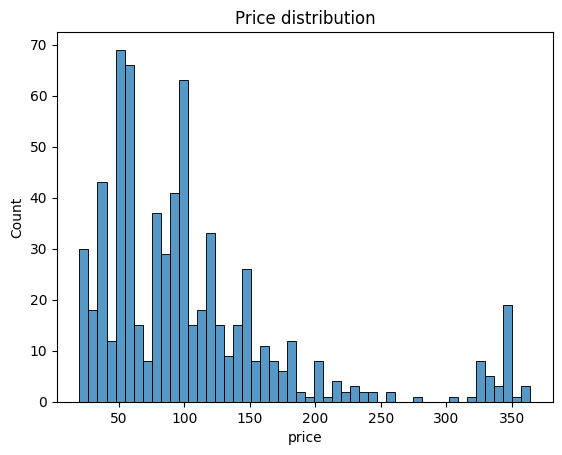

In [35]:
# Histogram of price
sns.histplot(df["price"], bins=50)
plt.title("Price distribution")
plt.show()

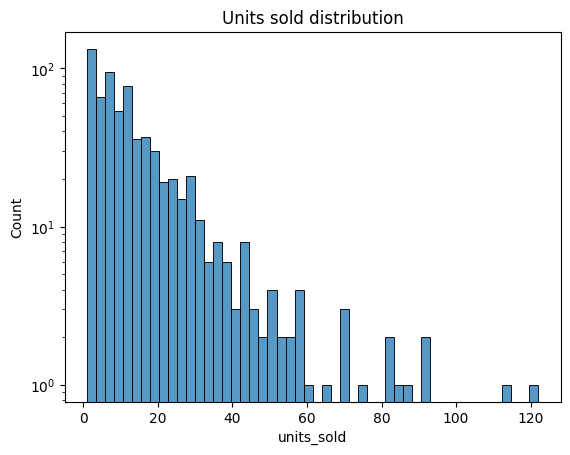

In [36]:
# Histogram of units sold (log-scale helps)
sns.histplot(df["units_sold"], bins=50)
plt.yscale("log")
plt.title("Units sold distribution")
plt.show()

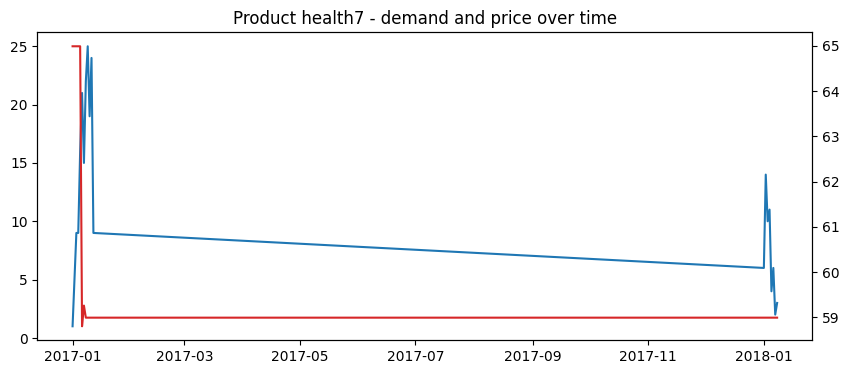

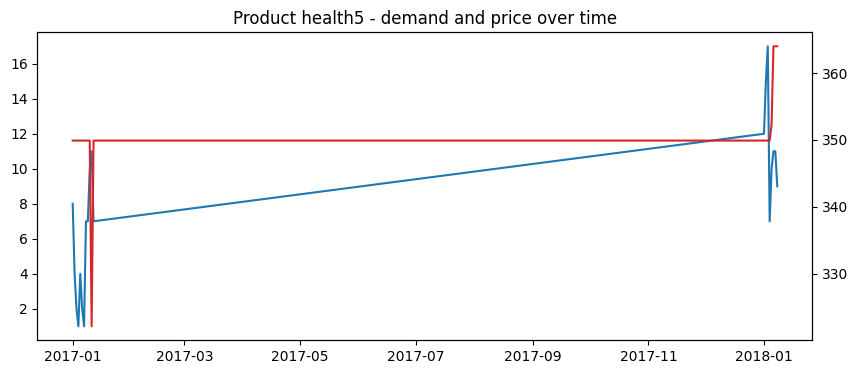

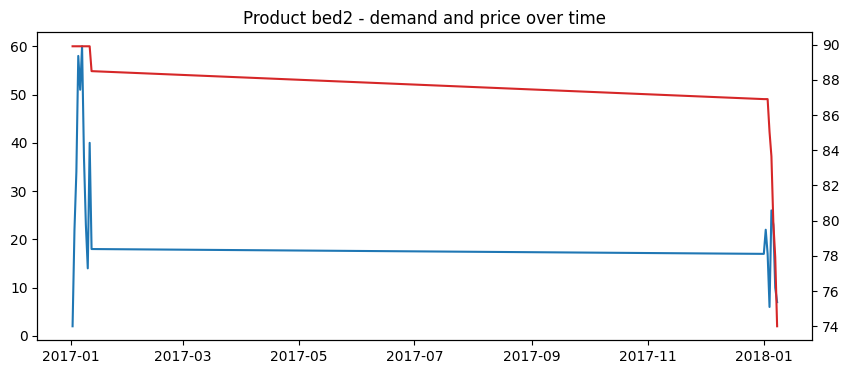

In [37]:
sample_products = df["product_id"].value_counts().head(3).index.tolist()

for pid in sample_products:
    tmp = df[df["product_id"] == pid].sort_values("date")
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(tmp["date"], tmp["units_sold"], color="tab:blue", label="Units sold")
    ax2 = ax1.twinx()
    ax2.plot(tmp["date"], tmp["price"], color="tab:red", label="Price")
    ax1.set_title(f"Product {pid} - demand and price over time")
    plt.show()

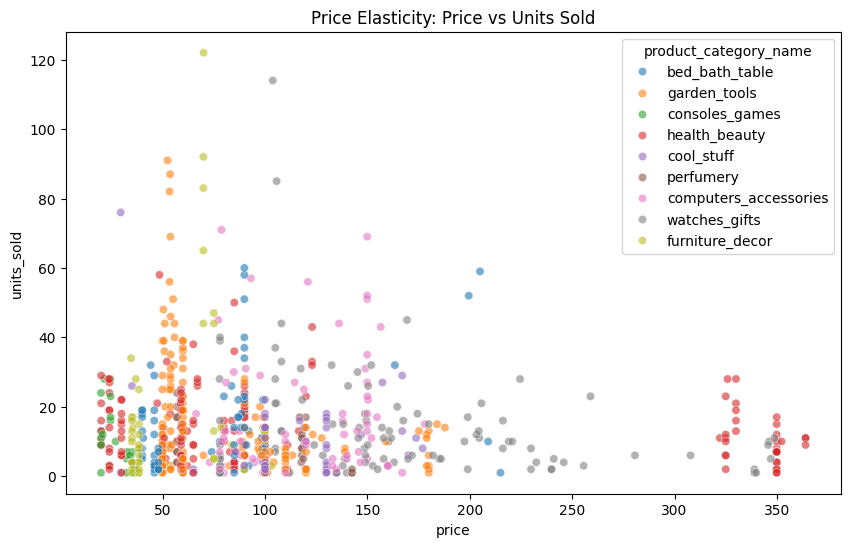

In [40]:
# Price vs Units Sold (Price Elasticity)
plt.figure(figsize=(10,6))
sns.scatterplot(x='price', y='units_sold', hue='product_category_name', data=df, alpha=0.6)
plt.title('Price Elasticity: Price vs Units Sold')
plt.show()

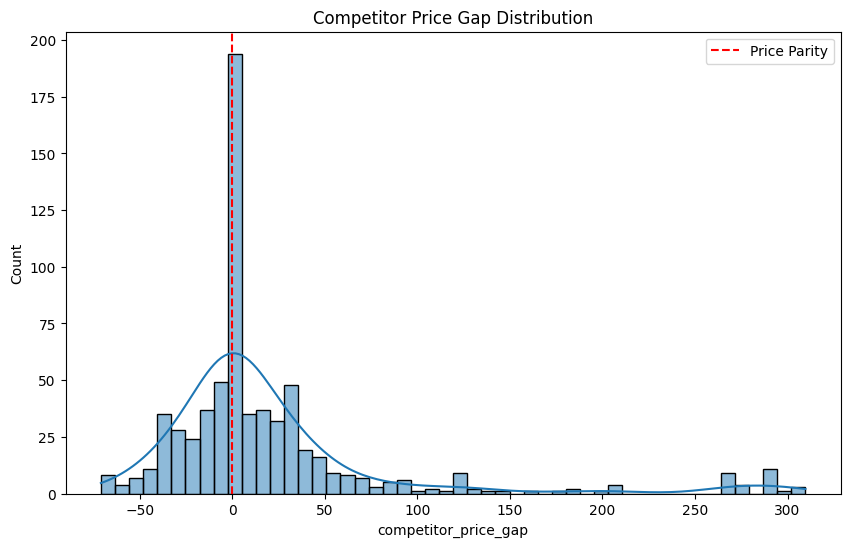

In [41]:
# Competitor Price Gap Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['competitor_price_gap'], kde=True, bins=50)
plt.axvline(x=0, color='red', linestyle='--', label='Price Parity')
plt.title('Competitor Price Gap Distribution')
plt.legend()
plt.show()

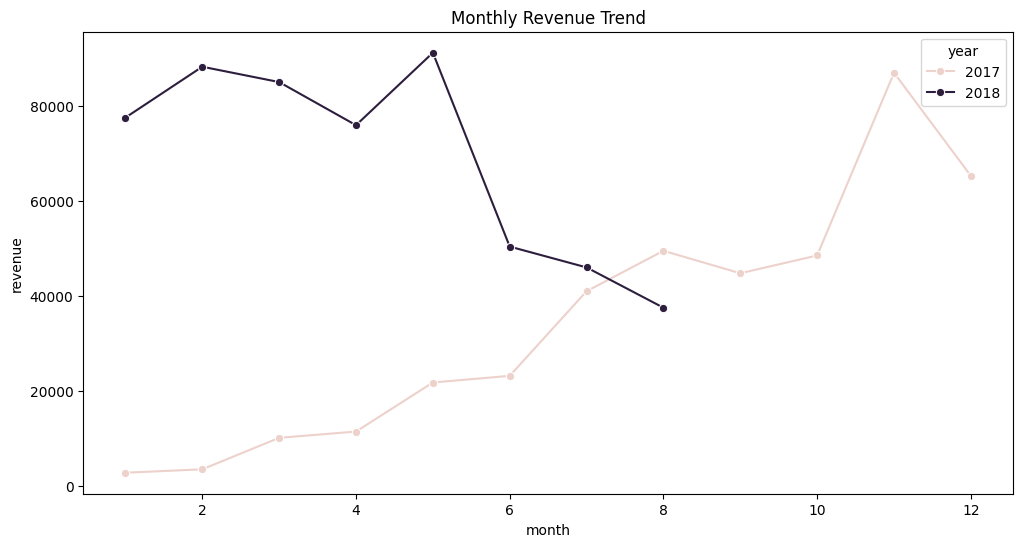

In [42]:
# Monthly Revenue Trend
monthly = df.groupby(['year','month'])['revenue'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='month', y='revenue', hue='year', data=monthly, marker='o')
plt.title('Monthly Revenue Trend')
plt.show()

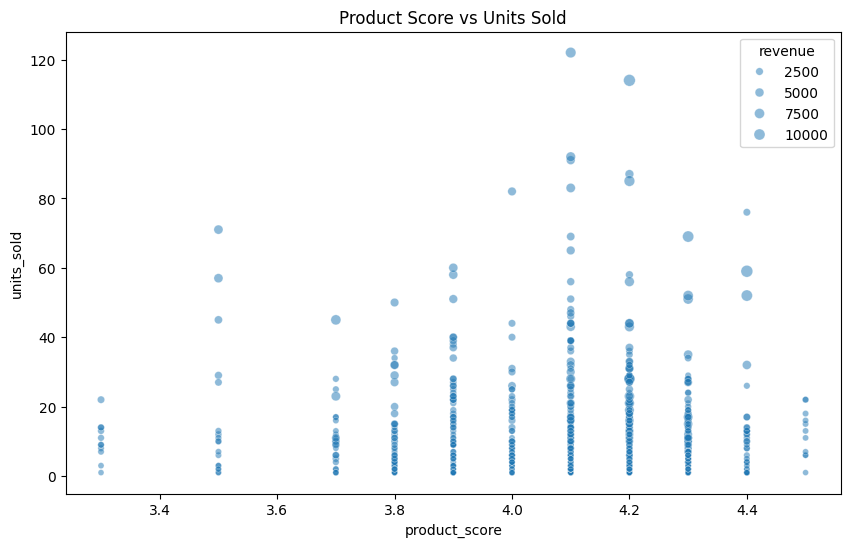

In [43]:
# Product Score vs Units Sold
plt.figure(figsize=(10,6))
sns.scatterplot(x='product_score', y='units_sold', size='revenue', data=df, alpha=0.5)
plt.title('Product Score vs Units Sold')
plt.show()

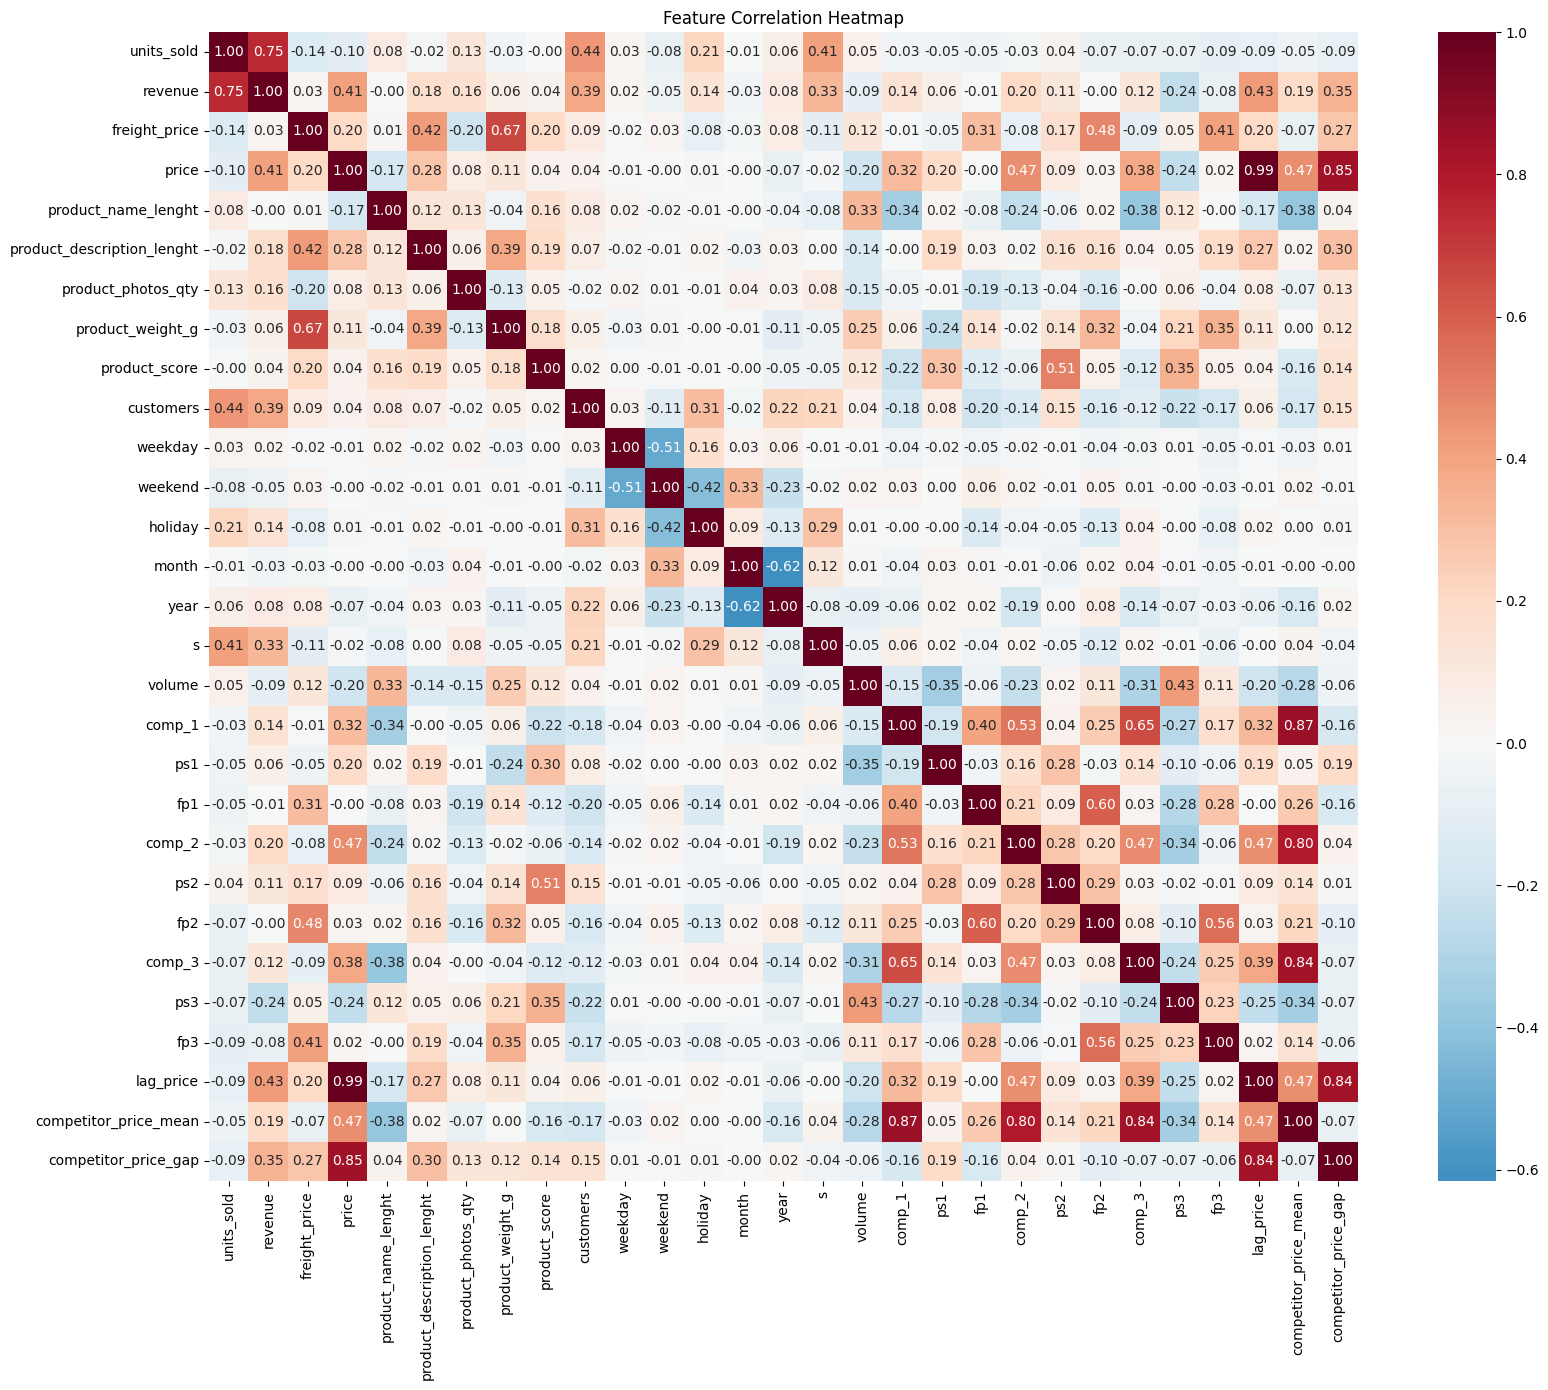

In [44]:
# Full Correlation Heatmap
plt.figure(figsize=(18,14))
numeric_cols = df.select_dtypes(include='number').columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

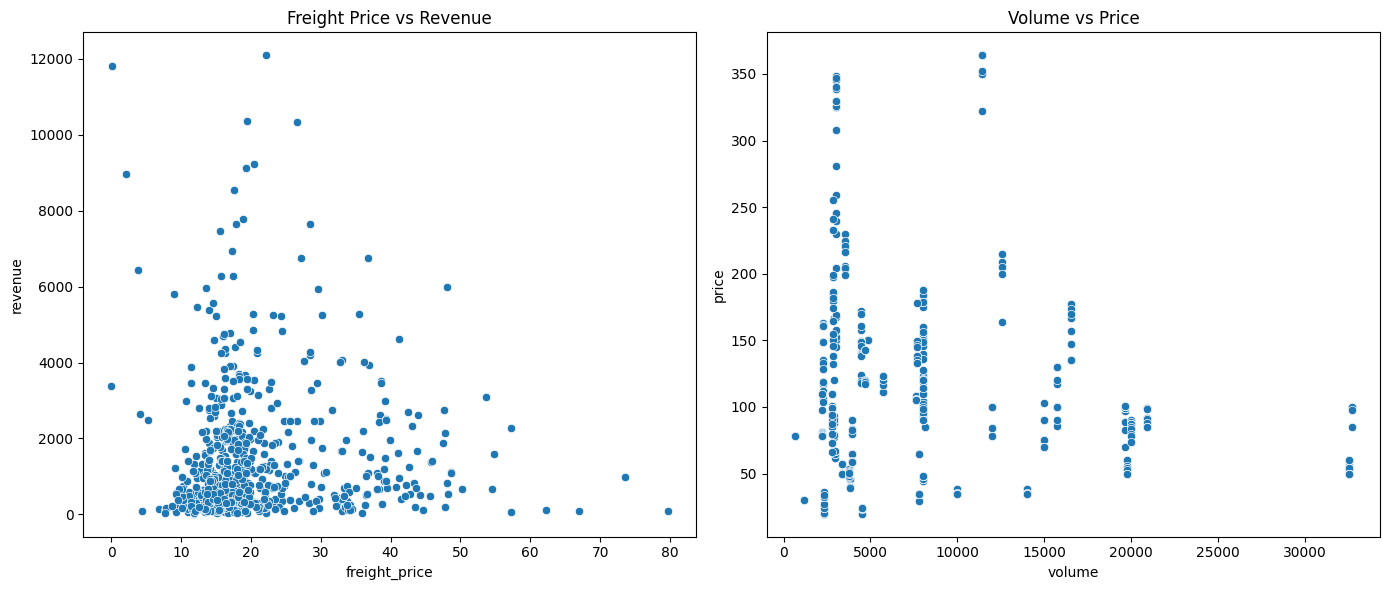

In [45]:
# Freight Price vs Revenue
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(x='freight_price', y='revenue', data=df, ax=axes[0])
axes[0].set_title('Freight Price vs Revenue')
sns.scatterplot(x='volume', y='price', data=df, ax=axes[1])
axes[1].set_title('Volume vs Price')
plt.tight_layout()
plt.show()